In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
from pathlib import Path
import re

dfs = []
ablation_dir = Path("ablation")
seen_aranges = set()

def _to_number(s):
    try:
        return int(s)
    except ValueError:
        return float(s)

# Use rglob to recurse into subdirectories so CSVs inside folders are found
for f in sorted(ablation_dir.rglob("*")):
    if not f.is_file():
        continue

    # try to extract numeric tokens from the filename; if not present try the parent folder name
    nums = re.findall(r"-?\d+(?:\.\d+)?", f.stem)
    if len(nums) < 3:
        # fallback: attempt to extract from parent folder (useful when files are inside named folders)
        nums = re.findall(r"-?\d+(?:\.\d+)?", f.parent.stem)

    if len(nums) < 3:
        # still not enough information to determine start/finish/step; skip this file
        continue

    start_val, finish_val, step_val = _to_number(nums[0]), _to_number(nums[1]), _to_number(nums[-1])

    ext = f.suffix.lower()
    try:
        if ext in {".csv", ".txt"}:
            tmp = pd.read_csv(f)
        elif ext in {".tsv"}:
            tmp = pd.read_csv(f, sep="\t")
        elif ext in {".parquet", ".pq"}:
            tmp = pd.read_parquet(f)
        else:
            continue
    except Exception as e:
        # If a file can't be read, skip it but report which one
        print(f"Skipping file {f!s}: {e}")
        continue

    tmp["start"] = start_val
    tmp["finish"] = finish_val
    tmp["step"] = step_val

    max_rows = 600_000

    # build a stable, hashable representation of the sequence
    arange_seq = tuple(np.round(np.arange(start_val, finish_val, step_val), 2).tolist())

    # skip if already processed
    if arange_seq in seen_aranges:
        continue

    # assign the scalar tuple key to every row (broadcast)
    tmp['arange'] = [arange_seq] * len(tmp)
    seen_aranges.add(arange_seq)

    if len(tmp) > max_rows:
        tmp = tmp.sample(n=max_rows, random_state=0).reset_index(drop=True)

    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [3]:
df

,MFtr,MFte,R_1,P_1,AE,Distance,Qnt,start,finish,step,arange
0,0.65,0.40,0.20,0.240,0.04,topsoe,DySyn-TS,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
1,0.35,0.55,0.99,0.770,0.22,NaN,SMM,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
2,0.95,0.60,0.48,0.000,0.48,NaN,MAX,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
3,0.50,0.45,0.71,0.590,0.12,NaN,CC,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
4,0.90,0.10,0.99,1.000,0.01,NaN,SMM,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
...,...,...,...,...,...,...,...,...,...,...,...
28799995,0.10,0.90,0.14,0.570,0.43,NaN,MAX,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799996,0.05,0.75,0.65,0.730,0.08,NaN,HDySyn,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799997,0.75,0.70,0.32,0.510,0.19,NaN,CC,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799998,0.80,0.95,0.18,0.393,0.21,topsoe,ACCSyn-TS,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"


In [4]:
df

,MFtr,MFte,R_1,P_1,AE,Distance,Qnt,start,finish,step,arange
0,0.65,0.40,0.20,0.240,0.04,topsoe,DySyn-TS,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
1,0.35,0.55,0.99,0.770,0.22,NaN,SMM,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
2,0.95,0.60,0.48,0.000,0.48,NaN,MAX,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
3,0.50,0.45,0.71,0.590,0.12,NaN,CC,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
4,0.90,0.10,0.99,1.000,0.01,NaN,SMM,0.1,0.9,0.35,"(0.1, 0.45, 0.8)"
...,...,...,...,...,...,...,...,...,...,...,...
28799995,0.10,0.90,0.14,0.570,0.43,NaN,MAX,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799996,0.05,0.75,0.65,0.730,0.08,NaN,HDySyn,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799997,0.75,0.70,0.32,0.510,0.19,NaN,CC,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"
28799998,0.80,0.95,0.18,0.393,0.21,topsoe,ACCSyn-TS,0.1,0.9,0.30,"(0.1, 0.4, 0.7)"


In [5]:
import plotly.express as px

# Parameters
y_col = "AE"            # change to "P_1" or "AE" if desired
n_per_group = 2000       # max rows per (start, finish) group
max_total = 33_600_000    # cap total rows before grouping to keep it responsive

if df.empty:
    print("DataFrame 'df' is empty. Nothing to plot.")
else:
    # Optional overall downsample for very large datasets
    df_pre = df.sample(n=max_total, random_state=0) if len(df) > max_total else df
    print(df_pre.shape)

    # Keep only needed columns and drop NaNs in the target
    df_box = df_pre[["start", "finish", y_col]].dropna()

    # Limit rows per (start, finish) to keep the plot manageable
    df_box = df_box.groupby(["start", "finish"], as_index=False, group_keys=False).head(n_per_group)

    # Label for x-axis: "start - finish"
    df_box["range"] = df_box["start"].map(lambda x: f"{x:g}") + " - " + df_box["finish"].map(lambda x: f"{x:g}")

    # Order x categories by (start, finish)
    order = (
        df_box[["range", "start", "finish"]]
        .drop_duplicates()
        .sort_values(["start", "finish"])
        ["range"].tolist()
    )

    # Box plot
    fig = px.box(
        df_box,
        x="range",
        y=y_col,
        points=False,  # set to "outliers" or "all" if you want to show points
        title=f"Boxplot of {y_col} by start-finish range"
    )
    fig.update_xaxes(title="start - finish", categoryorder="array", categoryarray=order)
    fig.update_yaxes(title=y_col)
    fig.show()

(28800000, 11)


c:\2Mestrado\score-drift-quantification\venv\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
import plotly.graph_objects as go

max_total = 20_000_000    # cap total rows before grouping to keep it responsive

# Create the interactive boxplot with dropdown for range filtering
if df.empty:
    print("DataFrame 'df' is empty. Nothing to plot.")
else:
    # Prepare data
    df_plot = df[["start", "finish", "step", "AE"]].dropna()
    df_plot = df.sample(n=max_total, random_state=0) if len(df) > max_total else df
    df_plot["range"] = df_plot["start"].astype(str) + " - " + df_plot["finish"].astype(str)
    
    # Get unique ranges and steps
    unique_ranges = sorted(df_plot["range"].unique())
    unique_steps = sorted(df_plot["step"].unique())
    
    # Create color palette
    colors = px.colors.qualitative.Set1[:len(unique_steps)]
    
    # Initialize figure
    fig = go.Figure()
    
    # Add traces for each range-step combination
    for range_val in unique_ranges:
        for i, step_val in enumerate(unique_steps):
            step_data = df_plot[(df_plot["range"] == range_val) & (df_plot["step"] == step_val)]
            
            if len(step_data) > 0:
                fig.add_trace(go.Box(
                    y=step_data["AE"],
                    name=f"Step {step_val}",
                    x=[f"Step {step_val}"] * len(step_data),
                    marker_color=colors[i % len(colors)],
                    visible=False,  # Start with all hidden except first range
                    legendgroup=f"Step {step_val}",
                    # boxpoints=False,
                    showlegend=(range_val == unique_ranges[0])  # Show legend only for first range
                ))
    
    # Make first range visible by default
    first_range_traces = len([s for s in unique_steps if len(df_plot[(df_plot["range"] == unique_ranges[0]) & (df_plot["step"] == s)]) > 0])
    for i in range(first_range_traces):
        fig.data[i].visible = True
    
    # Create dropdown buttons for range filtering
    dropdown_buttons = []
    
    # Individual range options
    trace_idx = 0
    for range_val in unique_ranges:
        visibility = [False] * len(fig.data)
        
        # Count traces for this range and make them visible
        range_trace_count = 0
        for step_val in unique_steps:
            if len(df_plot[(df_plot["range"] == range_val) & (df_plot["step"] == step_val)]) > 0:
                visibility[trace_idx] = True
                trace_idx += 1
                range_trace_count += 1
        
        dropdown_buttons.append({
            "label": f"Range {range_val}",
            "method": "update",
            "args": [{"visible": visibility}]
        })
    
    # Update layout
    fig.update_layout(
        title="Boxplot of AE by Step Values for Each Range",
        xaxis_title="Step",
        yaxis_title="AE",
        updatemenus=[{
            "buttons": dropdown_buttons,
            "direction": "down",
            "showactive": True,
            "x": 1.0,
            "xanchor": "left",
            "y": 1.02,
            "yanchor": "top"
        }],
        showlegend=True
    )
    
    fig.show()

In [ ]:
df['Qnt'].unique()

array(['DySyn-TS', 'SMM', 'MAX', 'CC', 'MS2', 'HDySyn', 'DyS-TS',
       'MAXSyn-TS', 'MS2Syn-TS', 'X', 'ACCSyn-TS', 'MS', 'PACCSyn-TS',
       'PACC', 'SMMSyn-TS', 'T50', 'ACC', 'MSSyn-TS', 'XSyn-TS', 'HDy',
       'PCC', 'T50Syn-TS'], dtype=object)

In [9]:
df_qnt = df[df['Qnt'] == 'DySyn-TS']

# Create a mesh/surface plot relating Step, Range, and AE
if df.empty:
    print("DataFrame 'df' is empty. Nothing to plot.")
else:
    # Prepare data for mesh plot
    df_mesh = df_qnt[["start", "finish", "step", "AE"]].dropna()
    
    # Sample data if too large
    # if len(df_mesh) > 100000:
    #     df_mesh = df_mesh.sample(n=100000, random_state=42)
    
    # Create mesh grid data
    # Group by start, finish, step and calculate mean AE
    mesh_data = df_mesh.groupby(['start', 'finish', 'step'])['AE'].mean().reset_index()
    
    # Create range column for better visualization (use actual range string)
    mesh_data['range_str'] = mesh_data['start'].astype(str) + ' - ' + mesh_data['finish'].astype(str)
    
    # Create the 3D surface plot
    fig = go.Figure()
    
    # Pivot data for surface plot using range_str instead of range_mid
    pivot_data = mesh_data.pivot_table(
        index='step', 
        columns='range_str', 
        values='AE', 
        aggfunc='mean'
    )
    
    # Get coordinates
    x_vals = pivot_data.columns  # range_str values
    y_vals = pivot_data.index    # step values
    z_vals = pivot_data.values   # AE values

    # Create surface plot
    fig.add_trace(go.Surface(
        x=list(range(len(x_vals))),  # Use numeric indices for x-axis
        y=y_vals,
        z=z_vals,
        colorscale='Viridis',
        name='AE Surface'
    ))
    
    # Update layout with custom x-axis labels
    fig.update_layout(
        title='3D Mesh Plot: Step vs Range vs AE',
        scene=dict(
            xaxis=dict(
                title='Range',
                tickmode='array',
                tickvals=list(range(len(x_vals))),
                ticktext=x_vals
            ),
            yaxis_title='Step',
            zaxis_title='AE',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=800,
        height=600
    )
    
    fig.show()
    
    # Also create a 2D heatmap as alternative visualization
    fig2 = go.Figure(data=go.Heatmap(
        x=x_vals,
        y=y_vals,
        z=z_vals,
        colorscale='Viridis',
        colorbar=dict(title="AE")
    ))
    
    fig2.update_layout(
        title='Heatmap: Step vs Range vs AE',
        xaxis_title='Range',
        yaxis_title='Step',
        width=800,
        height=600
    )
    
    fig2.show()


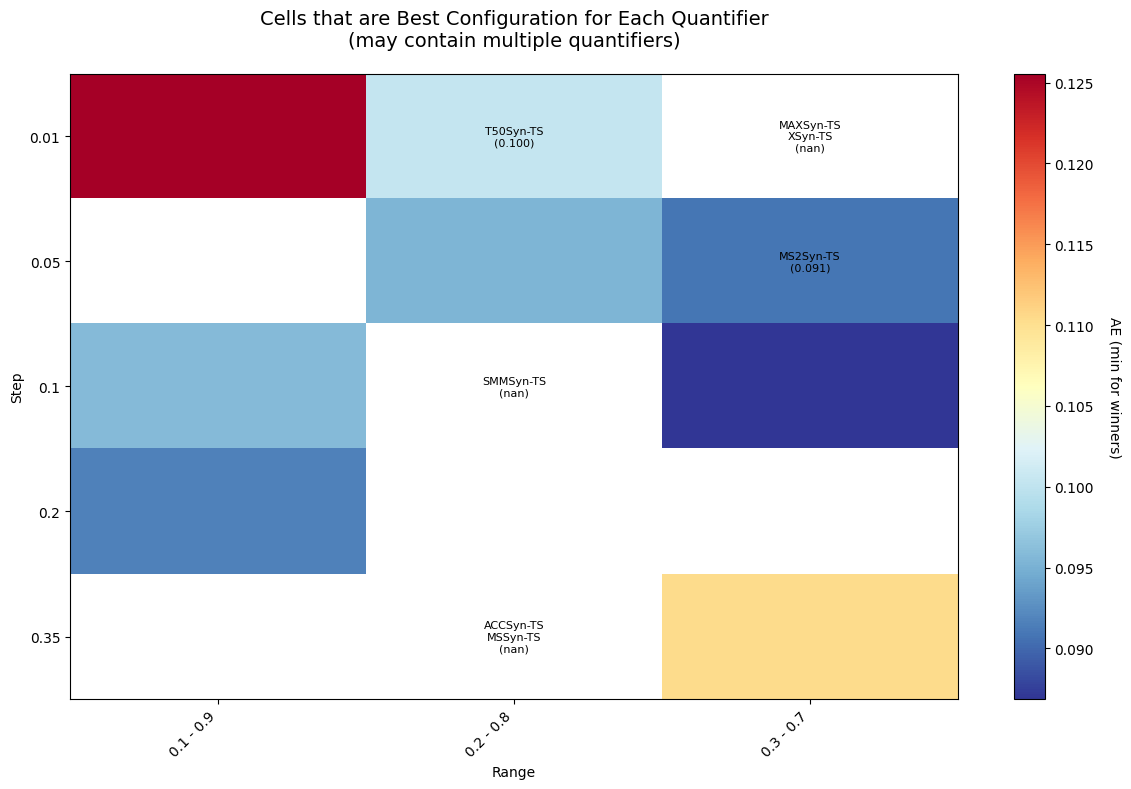


Best configuration(s) per quantifier:
ACCSyn-TS: 0.1 - 0.9 (step 0.20, AE 0.1018)
DySyn-TS: 0.3 - 0.7 (step 0.10, AE 0.0869)
HDySyn: 0.3 - 0.7 (step 0.05, AE 0.0909)
MAXSyn-TS: 0.2 - 0.8 (step 0.01, AE 0.1003)
MS2Syn-TS: 0.2 - 0.8 (step 0.05, AE 0.0955)
MSSyn-TS: 0.1 - 0.9 (step 0.20, AE 0.0916)
PACCSyn-TS: 0.3 - 0.7 (step 0.35, AE 0.1104)
SMMSyn-TS: 0.1 - 0.9 (step 0.10, AE 0.0958)
T50Syn-TS: 0.1 - 0.9 (step 0.01, AE 0.1255)
XSyn-TS: 0.2 - 0.8 (step 0.01, AE 0.1027)


In [32]:
# Create a heatmap showing which configuration is *best for each quantifier* (mark the cell where a quantifier achieves
# its best AE). A cell can contain multiple quantifiers if they share the same best configuration.
if df.empty:
    print("DataFrame 'df' is empty. Nothing to plot.")
else:
    # Prepare data for finding best quantifier configurations

    # Keep only relevant columns and quantifiers we care about (optionally filter by 'syn' if you want)
    # here we consider all quantifiers; if you want only those containing 'syn' re-enable the filter
    df_best = df[df['Qnt'].str.contains('syn', case=False, na=False)]
    df_best = df_best[["start", "finish", "step", "AE", "Qnt"]].dropna()

    # Sample to keep performance reasonable for very large datasets
    # if len(df_best) > 500_000:
    #     df_best = df_best.sample(n=500_000, random_state=42)

    # Create a range string column for positioning in the matrix
    df_best['range_str'] = df_best['start'].astype(str) + ' - ' + df_best['finish'].astype(str)

    # Compute mean AE for each (range_str, step, Qnt) configuration
    grouped = df_best.groupby(['range_str', 'step', 'Qnt'])['AE'].mean().reset_index()

    # For each quantifier find its minimum AE across all configurations
    min_per_q = grouped.groupby('Qnt')['AE'].min().reset_index().rename(columns={'AE': 'AE_min_q'})
    merged = grouped.merge(min_per_q, on='Qnt')

    # Keep only configurations that achieve the quantifier's minimum AE (allow ties)
    best_by_q = merged[np.isclose(merged['AE'], merged['AE_min_q'])].copy()

    # For each cell (range_str, step) collect the list of quantifiers that consider this cell their best config
    cell_winners = (
        best_by_q.groupby(['range_str', 'step'])['Qnt']
        .apply(lambda s: '\n'.join(sorted(s.astype(str).unique())))
        .reset_index(name='Qnt_list')
    )

    # For color mapping we can use the minimum AE observed among winners in that cell
    cell_ae = (
        best_by_q.groupby(['range_str', 'step'])['AE']
        .min()
        .reset_index(name='AE_min')
    )

    # Merge winners and AE
    cell_info = cell_winners.merge(cell_ae, on=['range_str', 'step'])
    
    # Get all possible combinations of range_str and step to ensure all cells are shown
    all_ranges = sorted(df_best['range_str'].unique())
    all_steps = sorted(df_best['step'].unique())
    all_combinations = pd.MultiIndex.from_product([all_ranges, all_steps], names=['range_str', 'step']).to_frame(index=False)
    
    # Merge with all combinations to fill missing cells
    cell_info_complete = all_combinations.merge(cell_info, on=['range_str', 'step'], how='left')
    
    # Fill NaN values for cells without winners
    cell_info_complete['Qnt_list'] = cell_info_complete['Qnt_list'].fillna('')
    cell_info_complete['AE_min'] = cell_info_complete['AE_min'].fillna(np.nan)  # Use NaN for empty cells

    # Pivot into matrix form
    pivot_best = cell_info_complete.pivot_table(index='step', columns='range_str', values='Qnt_list', aggfunc='first')
    pivot_ae = cell_info_complete.pivot_table(index='step', columns='range_str', values='AE_min', aggfunc='first')

    # Create matplotlib heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create masked array to handle NaN values
    masked_data = np.ma.masked_invalid(pivot_ae.values)
    
    # Create heatmap
    im = ax.imshow(masked_data, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')
    
    # Set ticks and labels
    ax.set_xticks(range(len(pivot_ae.columns)))
    ax.set_yticks(range(len(pivot_ae.index)))
    ax.set_xticklabels(pivot_ae.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot_ae.index)
    
    # Add text annotations
    for i in range(len(pivot_ae.index)):
        for j in range(len(pivot_ae.columns)):
            qnt_text = pivot_best.iloc[i, j]
            ae_val = pivot_ae.iloc[i, j]
            
            if pd.notna(qnt_text) and qnt_text != '':
                # Format text: quantifier names and AE value
                display_text = f"{qnt_text}\n({ae_val:.3f})"
                ax.text(j, i, display_text, ha='center', va='center', 
                       fontsize=8, wrap=True, color='black')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('AE (min for winners)', rotation=270, labelpad=20)
    
    # Set labels and title
    ax.set_xlabel('Range')
    ax.set_ylabel('Step')
    ax.set_title('Cells that are Best Configuration for Each Quantifier\n(may contain multiple quantifiers)', 
                 fontsize=14, pad=20)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save and show
    plt.savefig("ablation_result.svg", dpi=300, bbox_inches='tight')
    plt.show()

    # Print a compact summary: for each quantifier, list its best configuration(s)
    print("\nBest configuration(s) per quantifier:")
    print("=" * 70)
    for qnt, sub in best_by_q.groupby('Qnt'):
        configs = sub[['range_str', 'step', 'AE_min_q']].drop_duplicates()
        conf_str = ", ".join([f"{r} (step {s:.2f}, AE {a:.4f})" for r, s, a in configs.values])
        print(f"{qnt}: {conf_str}")

C:\Users\joaop\AppData\Local\Temp\ipykernel_8040\1201449206.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



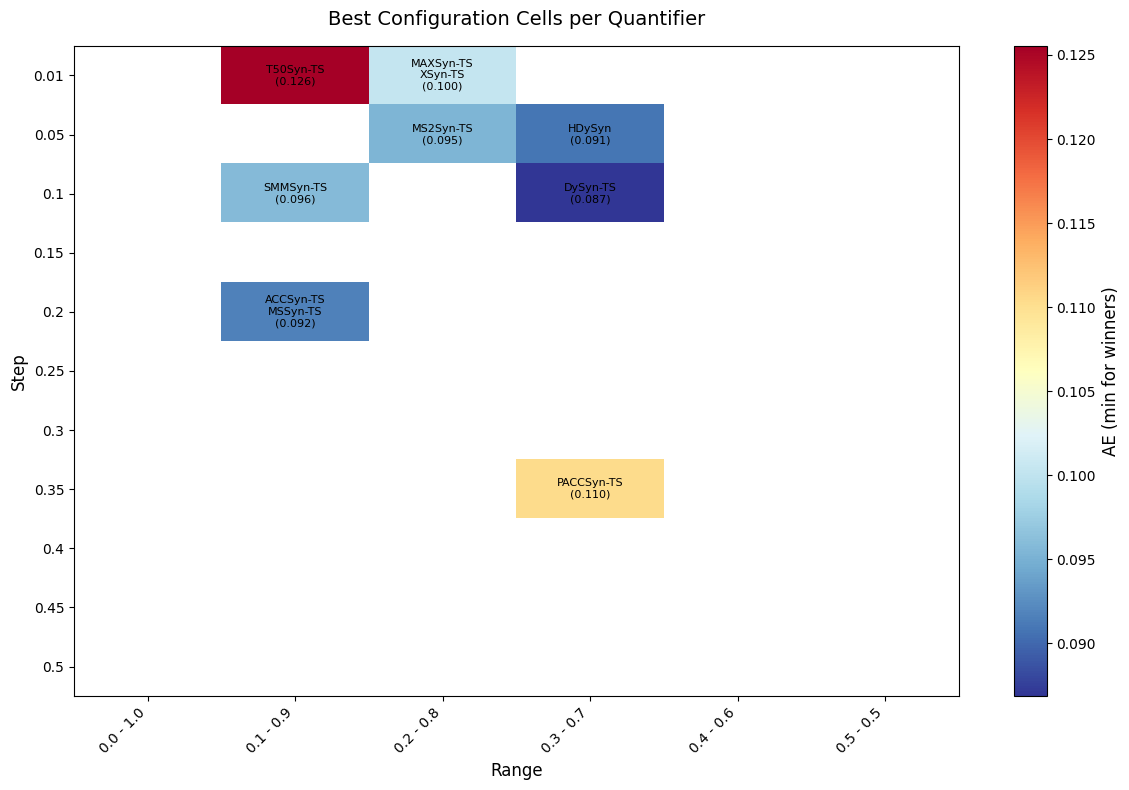


Best configuration(s) per quantifier:
ACCSyn-TS: 0.1 - 0.9 (step 0.20, AE 0.1018)
DySyn-TS: 0.3 - 0.7 (step 0.10, AE 0.0869)
HDySyn: 0.3 - 0.7 (step 0.05, AE 0.0909)
MAXSyn-TS: 0.2 - 0.8 (step 0.01, AE 0.1003)
MS2Syn-TS: 0.2 - 0.8 (step 0.05, AE 0.0955)
MSSyn-TS: 0.1 - 0.9 (step 0.20, AE 0.0916)
PACCSyn-TS: 0.3 - 0.7 (step 0.35, AE 0.1104)
SMMSyn-TS: 0.1 - 0.9 (step 0.10, AE 0.0958)
T50Syn-TS: 0.1 - 0.9 (step 0.01, AE 0.1255)
XSyn-TS: 0.2 - 0.8 (step 0.01, AE 0.1027)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- same preprocessing part ----
df_best = df[df['Qnt'].str.contains('syn', case=False)]
# df_best = df_best[["start", "finish", "step", "AE", "Qnt"]].dropna()

df_best['range_str'] = df_best['start'].astype(str) + ' - ' + df_best['finish'].astype(str)

grouped = df_best.groupby(['range_str', 'step', 'Qnt'])['AE'].mean().reset_index()
min_per_q = grouped.groupby('Qnt')['AE'].min().reset_index().rename(columns={'AE': 'AE_min_q'})
merged = grouped.merge(min_per_q, on='Qnt')
best_by_q = merged[np.isclose(merged['AE'], merged['AE_min_q'])].copy()

cell_winners = (
    best_by_q.groupby(['range_str', 'step'])['Qnt']
    .apply(lambda s: '\n'.join(sorted(s.astype(str).unique())))
    .reset_index(name='Qnt_list')
)

cell_ae = (
    best_by_q.groupby(['range_str', 'step'])['AE']
    .min()
    .reset_index(name='AE_min')
)

cell_info = cell_winners.merge(cell_ae, on=['range_str', 'step'])

all_ranges = sorted(df_best['range_str'].unique())
all_steps = sorted(df_best['step'].unique())
all_combinations = pd.MultiIndex.from_product([all_ranges, all_steps], names=['range_str', 'step']).to_frame(index=False)

cell_info_complete = all_combinations.merge(cell_info, on=['range_str', 'step'], how='left')
cell_info_complete['Qnt_list'] = cell_info_complete['Qnt_list'].fillna('')
cell_info_complete['AE_min'] = cell_info_complete['AE_min'].fillna(np.nan)

pivot_best = cell_info_complete.pivot(index='step', columns='range_str', values='Qnt_list')
pivot_ae = cell_info_complete.pivot(index='step', columns='range_str', values='AE_min')

# ---- matplotlib heatmap ----
fig, ax = plt.subplots(figsize=(12, 8))

# Matrix for AE values (for coloring)
im = ax.imshow(pivot_ae, cmap='RdYlBu_r', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('AE (min for winners)', fontsize=12)

# Axis labels
ax.set_xlabel('Range', fontsize=12)
ax.set_ylabel('Step', fontsize=12)
ax.set_title('Best Configuration Cells per Quantifier', fontsize=14, pad=15)

# Tick labels
ax.set_xticks(np.arange(len(pivot_ae.columns)))
ax.set_yticks(np.arange(len(pivot_ae.index)))
ax.set_xticklabels(pivot_ae.columns, rotation=45, ha='right')
ax.set_yticklabels(pivot_ae.index)

# Annotate each cell with quantifier names and AE
for i in range(len(pivot_ae.index)):
    for j in range(len(pivot_ae.columns)):
        q_text = str(pivot_best.iloc[i, j])
        ae_val = pivot_ae.iloc[i, j]
        if pd.notna(ae_val) and q_text.strip():
            ax.text(j, i, f"{q_text}\n({ae_val:.3f})",
                    ha='center', va='center', fontsize=8)
        elif not q_text.strip():
            ax.text(j, i, "", ha='center', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("ablation_result_matplotlib.svg", format="svg")
plt.show()

# ---- print summary ----
print("\nBest configuration(s) per quantifier:")
print("=" * 70)
for qnt, sub in best_by_q.groupby('Qnt'):
    configs = sub[['range_str', 'step', 'AE_min_q']].drop_duplicates()
    conf_str = ", ".join([f"{r} (step {s:.2f}, AE {a:.4f})" for r, s, a in configs.values])
    print(f"{qnt}: {conf_str}")


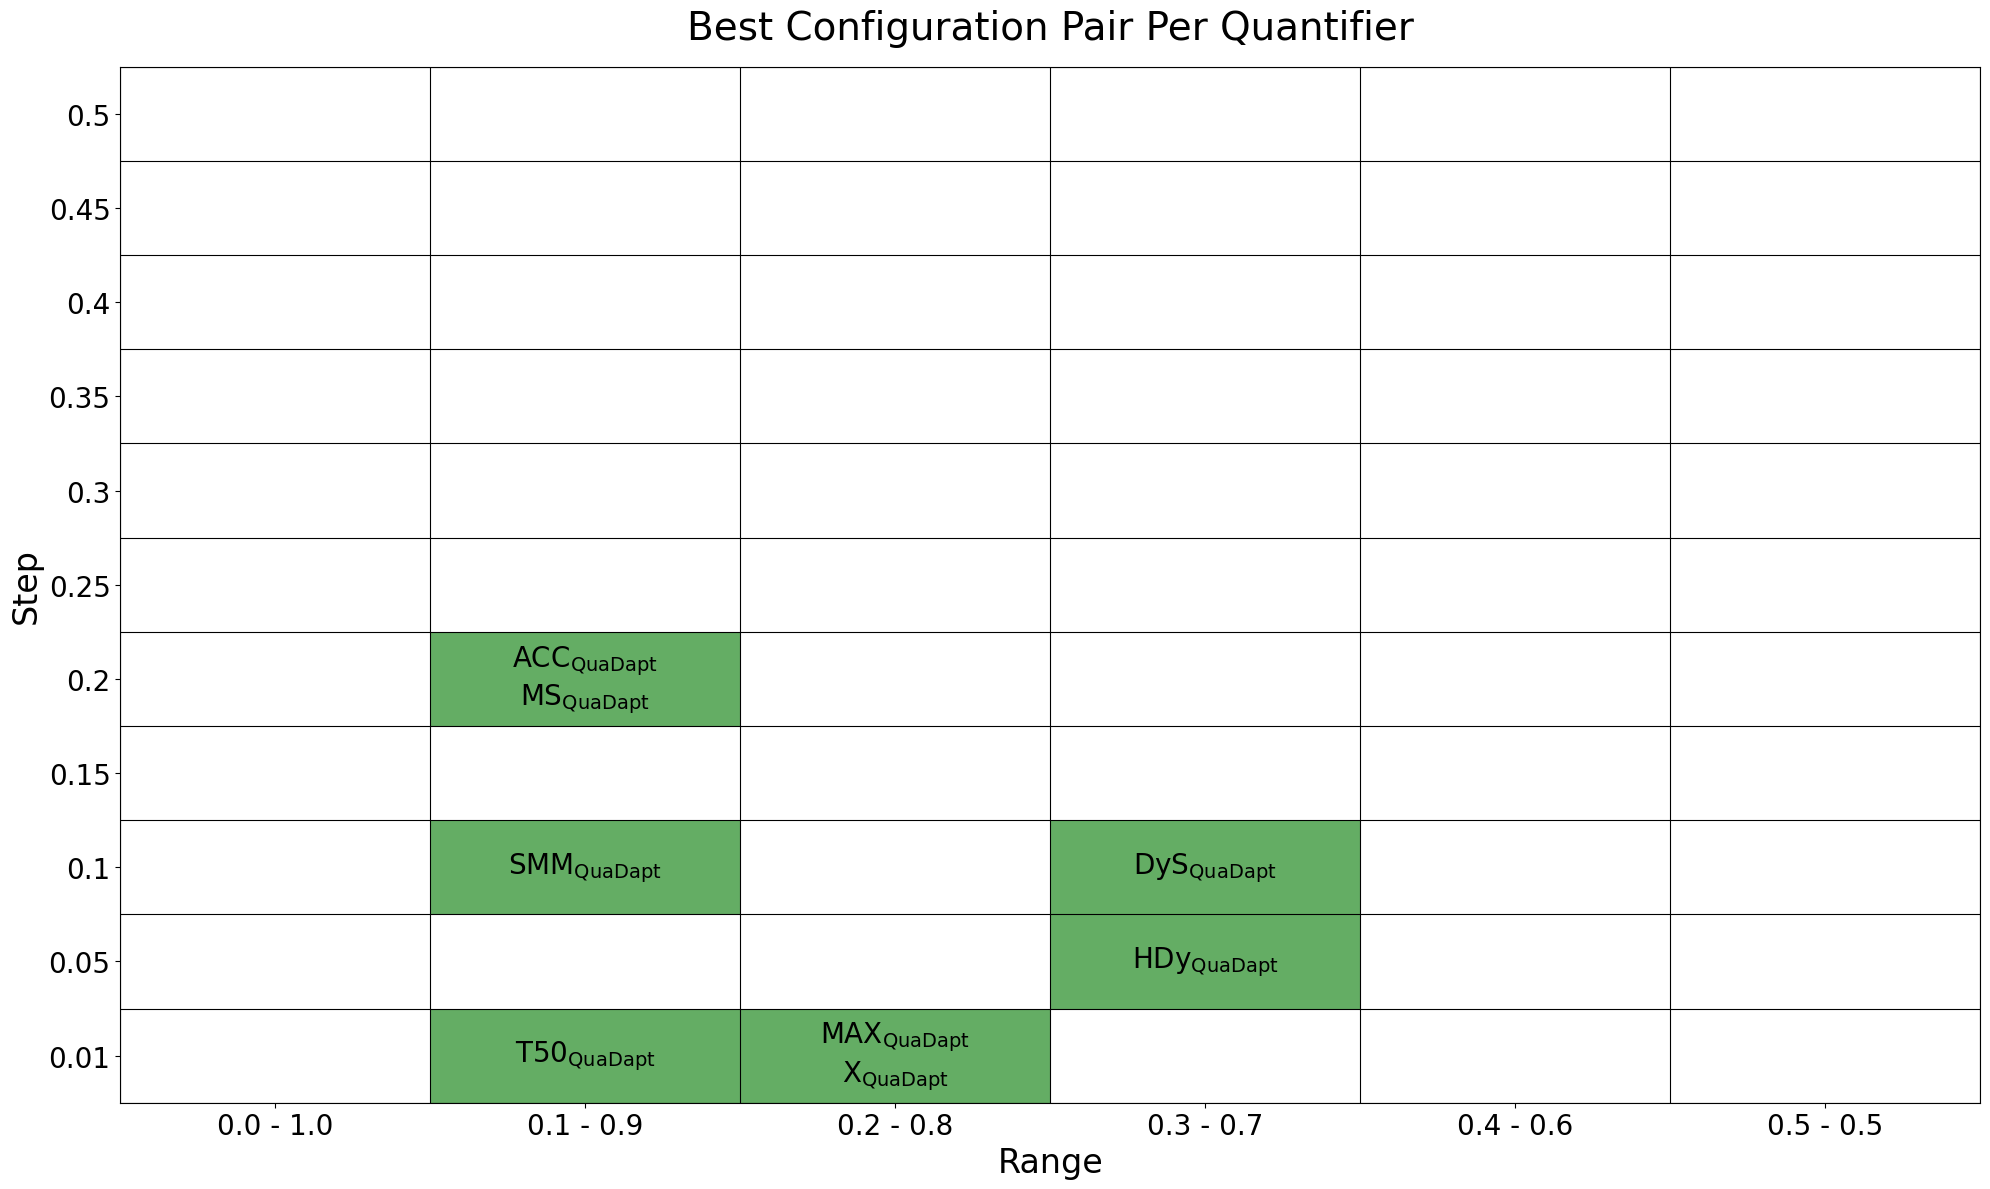


Best configuration(s) per quantifier:
ACCQuaDapt: 0.1 - 0.9 (step 0.20, AE 0.1018)
DySQuaDapt: 0.3 - 0.7 (step 0.10, AE 0.0869)
HDyQuaDapt: 0.3 - 0.7 (step 0.05, AE 0.0909)
MAXQuaDapt: 0.2 - 0.8 (step 0.01, AE 0.1003)
MSQuaDapt: 0.1 - 0.9 (step 0.20, AE 0.0916)
SMMQuaDapt: 0.1 - 0.9 (step 0.10, AE 0.0958)
T50QuaDapt: 0.1 - 0.9 (step 0.01, AE 0.1255)
XQuaDapt: 0.2 - 0.8 (step 0.01, AE 0.1027)


In [14]:
# ---- same preprocessing part ----
df_best = df[df['Qnt'].str.contains('syn', case=False)]

# Filter to only include specific quantifiers of interest
df_best = df_best[df_best['Qnt'].isin(['ACCSyn-TS', 'XSyn-TS', 'MAXSyn-TS', 'T50Syn-TS', 'DySyn-TS', 'HDySyn', 'MSSyn-TS', 'SMMSyn-TS'])]

# Rename quantifiers to use QuaDapt naming convention
df_best['Qnt'] = df_best['Qnt'].str.replace('Syn-TS', 'QuaDapt', regex=False)
df_best['Qnt'] = df_best['Qnt'].str.replace('Syn', 'QuaDapt', regex=False)
# Only apply the DyQuaDapt -> DySQuaDapt replacement if the quantifier is not HDyQuaDapt
df_best.loc[df_best['Qnt'] != 'HDyQuaDapt', 'Qnt'] = df_best.loc[df_best['Qnt'] != 'HDyQuaDapt', 'Qnt'].str.replace('DyQuaDapt', 'DySQuaDapt', regex=False)

# df_best = df_best[["start", "finish", "step", "AE", "Qnt"]].dropna()

df_best['range_str'] = df_best['start'].astype(str) + ' - ' + df_best['finish'].astype(str)

# Sample to keep performance reasonable for very large datasets
# df_best = df_best.sample(n=50, random_state=42)

def format_label(name):
    if name.endswith('QuaDapt'):
        base = name.replace('QuaDapt', '')
        return fr"$\mathrm{{{base}}}_{{\mathrm{{QuaDapt}}}}$"
    else:
        return fr"$\mathrm{{{name}}}$"
    
grouped = df_best.groupby(['range_str', 'step', 'Qnt'])['AE'].mean().reset_index()
min_per_q = grouped.groupby('Qnt')['AE'].min().reset_index().rename(columns={'AE': 'AE_min_q'})
merged = grouped.merge(min_per_q, on='Qnt')
best_by_q = merged[np.isclose(merged['AE'], merged['AE_min_q'])].copy()

cell_winners = (
    best_by_q.groupby(['range_str', 'step'])['Qnt']
    .apply(lambda s: '\n'.join(sorted(s.astype(str).unique())))
    .reset_index(name='Qnt_list')
)

all_ranges = sorted(df_best['range_str'].unique())
all_steps = sorted(df_best['step'].unique())
all_combinations = pd.MultiIndex.from_product([all_ranges, all_steps], names=['range_str', 'step']).to_frame(index=False)

cell_info_complete = all_combinations.merge(cell_winners, on=['range_str', 'step'], how='left')
cell_info_complete['Qnt_list'] = cell_info_complete['Qnt_list'].fillna('')

pivot_best = cell_info_complete.pivot(index='step', columns='range_str', values='Qnt_list')

# ---- matplotlib heatmap with grid inside - INCREASED SIZE ----
fig, ax = plt.subplots(figsize=(20, 12))  # Increased from (16, 8) to (20, 12)

# Create a light background
ax.imshow(np.ones(pivot_best.shape), cmap='Greys', alpha=0.1, aspect='auto')

# Reverse the y-axis
ax.invert_yaxis()

# Axis labels and title
ax.set_title('Best Configuration Pair Per Quantifier', fontsize=28, pad=20)  # Increased font size
ax.set_xlabel('Range', fontsize=24)  # Increased font size
ax.set_ylabel('Step', fontsize=24)   # Increased font size

# Tick labels
ax.set_xticks(np.arange(len(pivot_best.columns)))
ax.set_yticks(np.arange(len(pivot_best.index)))
ax.set_xticklabels(pivot_best.columns, ha='center', fontsize=20)  # Increased font size
ax.set_yticklabels(pivot_best.index, fontsize=20)  # Increased font size

# ---- ADD GRID LINES ----
ax.set_xticks(np.arange(-0.5, len(pivot_best.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot_best.index), 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)  # Slightly thicker lines
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate each cell with quantifier names that fill the entire cell
for i in range(len(pivot_best.index)):
    for j in range(len(pivot_best.columns)):
        q_text = str(pivot_best.iloc[i, j])
        if q_text.strip():
            # Green fill for cells that have quantifiers
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                                 facecolor="forestgreen", alpha=0.7,
                                 edgecolor='black', linewidth=0.6)  # Slightly thicker edge
            ax.add_patch(rect)
            
            # Format quantifier names using format_label function
            qnt_names = q_text.split('\n')
            formatted_names = [format_label(name) for name in qnt_names]
            formatted_text = '\n'.join(formatted_names)
            
            # Adjust font size based on number of quantifiers in cell
            num_quantifiers = len(qnt_names)
            if num_quantifiers == 1:
                font_size = 18
            elif num_quantifiers == 2:
                font_size = 18
            else:
                font_size = 12
            
            # Add text in the center
            ax.text(j, i, formatted_text, ha='center', va='center', fontsize=20,
                    weight='bold', wrap=True, color='black')

plt.tight_layout()
plt.savefig("ablation_result_full_cells_with_grid.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ---- print summary ----
print("\nBest configuration(s) per quantifier:")
print("=" * 70)
for qnt, sub in best_by_q.groupby('Qnt'):
    configs = sub[['range_str', 'step', 'AE_min_q']].drop_duplicates()
    conf_str = ", ".join([f"{r} (step {s:.2f}, AE {a:.4f})" for r, s, a in configs.values])
    print(f"{qnt}: {conf_str}")


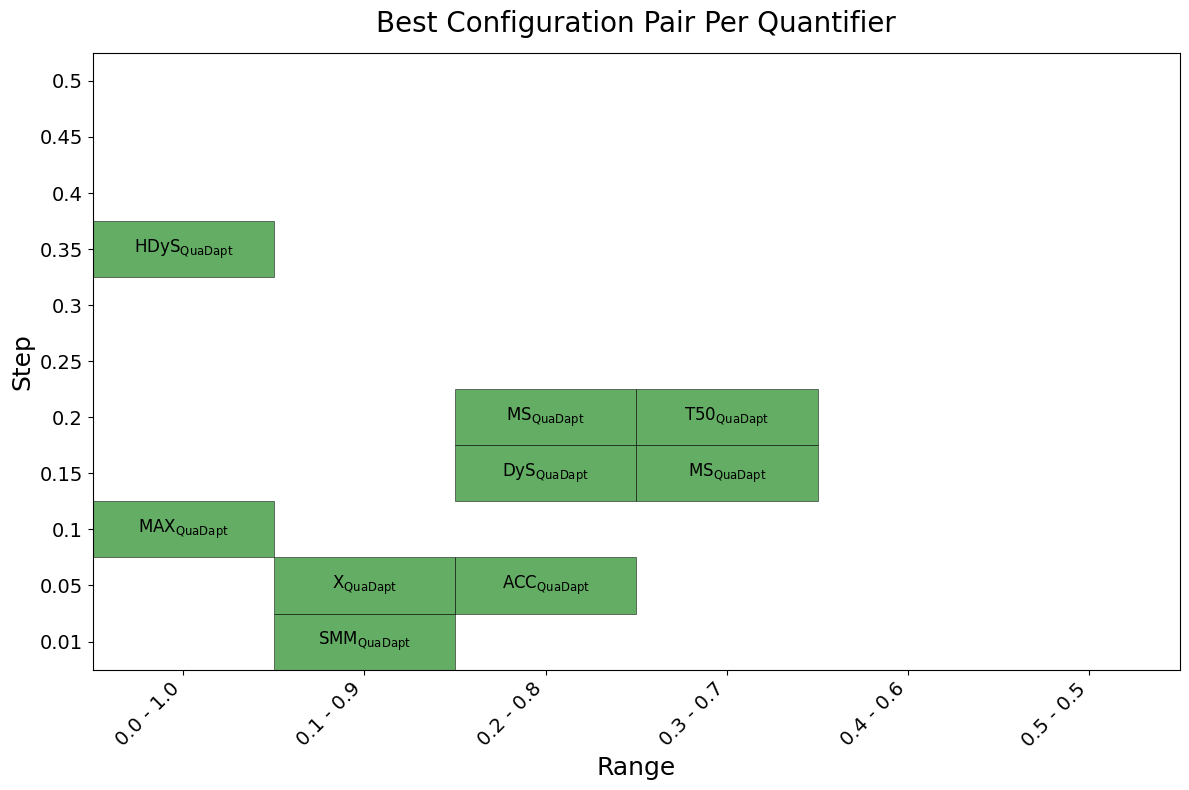


Best configuration(s) per quantifier:
ACCQuaDapt: 0.2 - 0.8 (step 0.05, AE 0.0100)
DySQuaDapt: 0.2 - 0.8 (step 0.15, AE 0.0000)
HDySQuaDapt: 0.0 - 1.0 (step 0.35, AE 0.0400)
MAXQuaDapt: 0.0 - 1.0 (step 0.10, AE 0.0000)
MSQuaDapt: 0.2 - 0.8 (step 0.20, AE 0.0100), 0.3 - 0.7 (step 0.15, AE 0.0100)
SMMQuaDapt: 0.1 - 0.9 (step 0.01, AE 0.0200)
T50QuaDapt: 0.3 - 0.7 (step 0.20, AE 0.0200)
XQuaDapt: 0.1 - 0.9 (step 0.05, AE 0.0000)


In [37]:
# ---- same preprocessing part ----
df_best = df[df['Qnt'].str.contains('syn', case=False, na=False)]

# Filter to only include specific quantifiers of interest
df_best = df_best[df_best['Qnt'].isin(['ACCSyn-TS', 'XSyn-TS', 'MAXSyn-TS', 'T50Syn-TS', 'DySyn-TS', 'HDySyn', 'MSSyn-TS', 'SMMSyn-TS'])]

# Rename quantifiers to use QuaDapt naming convention
df_best['Qnt'] = df_best['Qnt'].str.replace('Syn-TS', 'QuaDapt', regex=False)
df_best['Qnt'] = df_best['Qnt'].str.replace('Syn', 'QuaDapt', regex=False)
df_best['Qnt'] = df_best['Qnt'].str.replace('DyQuaDapt', 'DySQuaDapt', regex=False)

df_best = df_best[["start", "finish", "step", "AE", "Qnt"]].dropna()

df_best['range_str'] = df_best['start'].astype(str) + ' - ' + df_best['finish'].astype(str)

# Sample to keep performance reasonable for very large datasets
df_best = df_best.sample(n=50, random_state=42)

def format_label(name):
    if name.endswith('QuaDapt'):
        base = name.replace('QuaDapt', '')
        return fr"$\mathrm{{{base}}}_{{\mathrm{{QuaDapt}}}}$"
    else:
        return fr"$\mathrm{{{name}}}$"
    
grouped = df_best.groupby(['range_str', 'step', 'Qnt'])['AE'].mean().reset_index()
min_per_q = grouped.groupby('Qnt')['AE'].min().reset_index().rename(columns={'AE': 'AE_min_q'})
merged = grouped.merge(min_per_q, on='Qnt')
best_by_q = merged[np.isclose(merged['AE'], merged['AE_min_q'])].copy()

cell_winners = (
    best_by_q.groupby(['range_str', 'step'])['Qnt']
    .apply(lambda s: '\n'.join(sorted(s.astype(str).unique())))
    .reset_index(name='Qnt_list')
)

all_ranges = sorted(df_best['range_str'].unique())
all_steps = sorted(df_best['step'].unique())
all_combinations = pd.MultiIndex.from_product([all_ranges, all_steps], names=['range_str', 'step']).to_frame(index=False)

cell_info_complete = all_combinations.merge(cell_winners, on=['range_str', 'step'], how='left')
cell_info_complete['Qnt_list'] = cell_info_complete['Qnt_list'].fillna('')

pivot_best = cell_info_complete.pivot(index='step', columns='range_str', values='Qnt_list')

# ---- matplotlib heatmap with grid inside ----
fig, ax = plt.subplots(figsize=(12, 8))

# Create a light background
ax.imshow(np.ones(pivot_best.shape), cmap='Greys', alpha=0.1, aspect='auto')

# Reverse the y-axis
ax.invert_yaxis()

# Axis labels and title
ax.set_title('Best Configuration Pair Per Quantifier', fontsize=20, pad=15)
ax.set_xlabel('Range', fontsize=18)
ax.set_ylabel('Step', fontsize=18)

# Tick labels
ax.set_xticks(np.arange(len(pivot_best.columns)))
ax.set_yticks(np.arange(len(pivot_best.index)))
ax.set_xticklabels(pivot_best.columns, rotation=45, ha='right', fontsize=14)
ax.set_yticklabels(pivot_best.index, fontsize=14)

# ---- ADD GRID LINES ----
# ax.set_xticks(np.arange(-0.5, len(pivot_best.columns), 1), minor=True)
# ax.set_yticks(np.arange(-0.5, len(pivot_best.index), 1), minor=True)
# ax.grid(which="minor", color="black", linestyle="-", linewidth=0.7)
# ax.tick_params(which="minor", bottom=False, left=False)

# Annotate each cell with quantifier names that fill the entire cell
for i in range(len(pivot_best.index)):
    for j in range(len(pivot_best.columns)):
        q_text = str(pivot_best.iloc[i, j])
        if q_text.strip():
            # Green fill for cells that have quantifiers
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                                 facecolor="forestgreen", alpha=0.7,
                                 edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
            
            # Format quantifier names using format_label function
            qnt_names = q_text.split('\n')
            formatted_names = [format_label(name) for name in qnt_names]
            formatted_text = '\n'.join(formatted_names)
            
            # Add text in the center
            ax.text(j, i, formatted_text, ha='center', va='center', fontsize=12,
                    weight='bold', wrap=True, color='black')

plt.tight_layout()
plt.savefig("ablation_result_full_cells_with_grid.svg", format="svg")
plt.show()


# ---- print summary ----
print("\nBest configuration(s) per quantifier:")
print("=" * 70)
for qnt, sub in best_by_q.groupby('Qnt'):
    configs = sub[['range_str', 'step', 'AE_min_q']].drop_duplicates()
    conf_str = ", ".join([f"{r} (step {s:.2f}, AE {a:.4f})" for r, s, a in configs.values])
    print(f"{qnt}: {conf_str}")
